# Inference in Linear Dynamical Systems

In a [previous post](https://pschulam.github.io/posts/the_kalman_filter/), I described the basic ideas behind the Kalman filter for tracking in linear dynamical systems and implemented the algorithm in Python. The Kalman filter turns out to be a key step in several other analyses that we may want to perform for time series data. In this post, I'll show how an understanding of the Kalman filter lays foundations for three operations: `simulate`, `score`, and `smooth`.

<!-- TEASER_END -->

# Kalman Filter Recap

The Kalman filter is an algorithm for *tracking* the latent state of a system over time given a sequence of measurements. The filter recursively applies two fundamental operations (`correct` and `predict`), and allows us to compute

$$
\alpha_k(x) = p(x_k = x \mid y_{1:k}) \propto
\underbrace{p \big( x_k \mid y_{1:(k - 1)} \big)}_{\text{Predict}}
\underbrace{p \big( y_k \mid x_k \big)}_{\text{Correct}},
$$

where $y_{1:k}$ is a sequence of measurements observed at times $1, \ldots, k$. I'll refer to these distributions as the *filtered distributions* for the latent state. If this notation is unfamiliar to you, you can read my [previous post](https://pschulam.github.io/posts/the_kalman_filter/) to get up to speed. In the rest of this post, we'll see what we can actually do with these filtered distributions.

As a starting point, here is the Python code I developed in the previous post along with a few utility functions for working with `system` dictionaries.

In [59]:
%matplotlib inline

from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import cholesky
from scipy.linalg import solve_triangular

solve_tril = partial(solve_triangular, lower=True)
solve_triu = partial(solve_triangular, lower=False)

'''
Assume that the system variable has the following structure.

system = {
    'dyn': (F, G, Q),
    'obs': (H, R)
}
'''

def kalman_filter(S, m, C, Y, U):
    for y, u in zip(Y, U):
        m, C = kalman_step(S, m, C, y, u)
    return m, C

def kalman_step(S, m, C, y, u):
    m_c, C_c = correct(*obs_model(S), m, C, y)
    m_p, C_p = predict(*dyn_model(S), m_c, C_c, u)
    return m_p, C_p

def correct(H, R, m, C, y):
    L = cholesky(H @ C @ H.T + R)
    Z = solve_tril(L, H @ C)
    X = solve_triu(L.T, Z)
    m_c = m + X.T @ (y - H @ m)
    C_c = C - Z.T @ Z
    return m_c, C_c

def predict(F, G, Q, m, C, u):
    m_p = F @ m + G @ u
    C_p = F @ C @ F.T + Q
    return m_p, C_p

def n_hidden(system):
    F, _, _ = system['dyn']
    return len(F)

def n_inputs(system):
    _, G, _ = system['dyn']
    return G.shape[1]

def n_observed(system):
    H, _ = system['obs']
    return len(H)

def dyn_model(system):
    return system['dyn']

def obs_model(system):
    return system['obs']

# The Stochastic Spring System

As an example, we use a stochastic spring system in this post to test out some of the procedures. Here's a function to create this system.

In [86]:
def new_stochastic_spring(nu=1.0, gamma=1.0, dt=1e-2):
    # These are the parameters in a continuous-time LDS.
    # They will be converted to discrete time parameters below.

    F = np.array([
        [0.0, 1.0],
        [-nu**2, -gamma]
    ])

    G = np.array([
        [0.0],
        [1.0]
    ])
    
    Q = np.array([
        [1e-8, 0.0],
        [0.0, 0.1**2]
    ])

    H = np.array([
        [1.0, 0.0]
    ])
    
    R = np.array([
        [0.1**2]
    ])
    
    system = {'dyn': (F, G, Q), 'obs': (H, R)}
    return continuous_to_discrete(system, dt)
    
def continuous_to_discrete(system, dt):
    F, G, Q = dyn_model(system)
    H, R = obs_model(system)
    
    discrete = {
        'dyn': (
            np.eye(n_hidden(system)) + F * dt,
            np.copy(G),
            Q * dt
        ),
        'obs': (
            np.copy(H),
            np.copy(R)
        )
    }
    
    return discrete

def discretize(dt, t, y, fill_value):
    _, *yshape = y.shape
    k = t2k(dt, t)
    Y = np.full((max(k) + 1,) + tuple(yshape), fill_value)
    Y[k] = y
    return k, Y

def undiscretize(dt, k, Y):
    t = k2t(dt, k)
    y = Y[k]
    return t, y

def t2k(dt, t):
    return np.floor(t / dt).astype(int)

def k2t(dt, k):
    return (k * dt).astype(float)

dt = 1e-2
spring = new_stochastic_spring(dt=dt)

m = np.array([1.0, 0.0])
C = np.eye(2)

T = 6.0
t = np.arange(0.0, T, dt)

U0 = np.zeros((len(t), n_inputs(spring)))
U1 = np.zeros((len(t), n_inputs(spring)))
U1[t2k(dt, np.array([1.5, 4.0]))] = np.array([1.0, 1.0])[:, None]

np.random.seed(0)
t_obs = 2.0 * np.sort(np.random.uniform(size=10))

# Simulate

We'll start with the simplest operation: `simulate`. This doesn't actually build on the Kalman filter, but it does connect with it in an important way, which we'll get to soon. This operation is conceptually straightforward: we simply want to simulate latent states and measurements from a linear dynamical system. In addition to the system, this operation requires an initial belief over the first latent state and a sequence of inputs. We'll assume that the initial belief is Gaussian with parameters $m$ and $C$ and that the sequence of inputs $u_{1:T}$ is the same length as the number of steps we'd like to simulate.

To implement the operation, I'm going to break `simulate` down into two simpler operations: `measure` and `advance`. `measure` takes a latent state and produces a noisy observation of it according to the system's measurement model. `advance` takes a latent state and produces the conditional distribution over the subsequent state according to the system's dynamics model.

Here is some Python code implementing `simulate`.

In [87]:
mvn = np.random.multivariate_normal

def simulate(S, m, C, U):
    n_steps = len(U)
    X = np.zeros((n_steps, n_hidden(S)))
    Y = np.zeros((n_steps, n_observed(S)))
    for i, u in enumerate(U):
        X[i] = mvn(m, C)
        Y[i] = measure(*obs_model(S), X[i])
        m, C = advance(*dyn_model(S), X[i], u)
    return X, Y

def measure(H, R, x):
    return mvn(H @ x, R)

def advance(F, G, Q, x, u):
    return F @ x + G @ u, Q

And we can test that it works by simulating from the stochastic spring model.

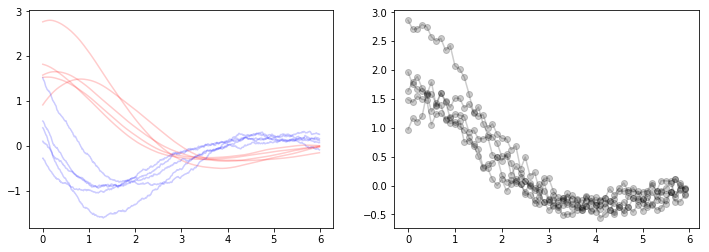

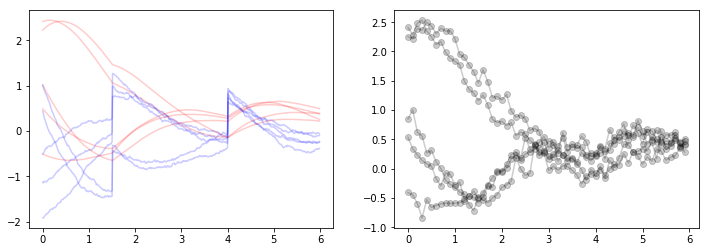

In [88]:
np.random.seed(0)
samples0 = [simulate(spring, m, C, U0) for _ in range(5)]
samples1 = [simulate(spring, m, C, U1) for _ in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for X, Y in samples0:
    axes[0].plot(t, X[:, 0], 'r-', alpha=0.2)
    axes[0].plot(t, X[:, 1], 'b-', alpha=0.2)
    axes[1].plot(t[::10], Y[::10], 'k-o', alpha=0.2)
    
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for X, Y in samples1:
    axes[0].plot(t, X[:, 0], 'r-', alpha=0.2)
    axes[0].plot(t, X[:, 1], 'b-', alpha=0.2)
    axes[1].plot(t[::10], Y[::10], 'k-o', alpha=0.2)

## Forecast

Now that we know how to simulate, we can make the connection between simulation and filtering. Recall that the filtering algorithm produces a belief about the latent state *just after* the final observation. We can feed this belief directly into the `simulate` operation in order to *forecast* the future state of the system given some observations.

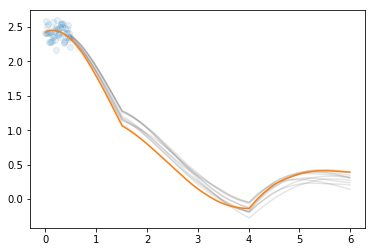

In [91]:
X, Y = samples1[0]

n_obs = 50
m_new, C_new = kalman_filter(spring, m, C, Y[:n_obs], U1[:n_obs])

for _ in range(10):
    X_hat, _ = simulate(spring, m_new, C_new, U1[n_obs:])
    plt.plot(t[n_obs:], X_hat[:, 0], 'k-', alpha=0.1)
    
plt.plot(t[:n_obs], Y[:n_obs], 'o', alpha=0.1)
plt.plot(t, X[:, 0], '-')

# Score

The `score` operation computes the log probability of observations according to the probability distribution defined by the dynamics and measurement models of the system. This operation is slightly more complicated than it may seem at first glance because we do not observe the state of the system, and so must integrate over those values:

$$
p(y_{1:k}) = \int p(y_{1:k} \mid x_{1:k}) p(x_{1:k}) {\sf d}^k x_{1:k}
$$

We can compute the score as a by-product of the Kalman filter. The joint probability of the observations can be written

$$
p(y_{1:k}) = p(y_1) \prod_{j=1}^k p(y_j \mid y_{1:(j - 1)}).
$$

For any term in the product above, we have

$$
p(y_k \mid y_{1:(k-1)}) = \int
\underbrace{p(y_k \mid x_k)}_{\text{(A)}}
\underbrace{p(x_k \mid y_{1:(k-1)})}_{\text{(B)}}
{\sf d} x_k.
$$

Term (A) is given by the system's measurement model, and term (B) is the output of the Kalman filter after processing the first $k - 1$ measurements. Because the mean of the conditional distribution in (A) is a linear function of $x_k$ and because term (B) is multivariate normal, we can compute this integral in closed form. Let $m_{k \mid k-1}$ and $C_{k \mid k - 1}$ denote the pre-correction belief about $x_k$ at step $k$, then $p(y_k \mid y_{1:(k-1)})$ is

$$
p(y_k \mid y_{1:(k-1)}) \sim \mathcal{N}
\big(
H m_{k \mid k - 1},
H C_{k \mid k - 1} H^\top + R
\big).
$$

We can evaluate this density using a recursion similar to the filter.

In [92]:
def score(S, m, C, Y, U):
    ll = 0.0
    for y, u in zip(Y, U):
        ll = ll + score_step(*obs_model(S), m, C, y)
        m, C = predict(*dyn_model(S), m, C, u)
    return ll
    
def score_step(H, R, m, C, y):
    L = cholesky(H @ C @ H.T + R)
    return mvn_logpdf_cho(y, H @ m, L)

log2pi = np.log(2.0 * np.pi)

def mvn_logpdf_cho(y, m, L):
    n = len(y)
    r = solve_tril(L, y - m)
    return -0.5 * (n * log2pi + cho_logdet(L) + np.dot(r, r))

def cho_logdet(L):
    return np.sum(2.0 * np.log(np.diag(L)))

# Smooth

The final operation that we'll implement in this post is `smooth`. I'm going to deviate slightly from what people typically mean when they say "smooth". Usually, the smoothing procedure computes the distribution

$$
p(x_k \mid y_{1:T})
$$

for all $k$. The difference between the smoothed distributions and the filtered distributions ($\alpha_k$) is that the smoothed distributions carry information *backwards* from observations after time $k$. Instead of computing these distributions, our implementation will draw samples from the posterior distribution

$$
p(x_{1:T} \mid y_{1:T}).
$$

To sample from this distribution, we're again going to use the chain rule (as we did when we implemented the `score` operation), but this time in *reverse*. We can write the target posterior as

$$
p(x_{1:T} \mid y_{1:T}) = p(x_T \mid y_{1:T}) \prod_{k=1}^T p(x_k \mid x_{k + 1}, y_{1:T}).
$$

I want to highlight a few things about the right hand side. First, note that

$$
p(x_T = x \mid y_{1:T}) = \alpha_T(x) =
\int
\underbrace{p(x_{T + 1} \mid y_{1:T})}_{\text{(A)}}
p(x_T = x \mid x_{T + 1}, y_{1:T})
{\sf d} x_{T+1}.
$$

Term (A) is the output of the Kalman filter after processing $y_{1:T}$, and the second term is

$$
p(x_T \mid x_{T + 1}, y_{1:T})
\propto
p(x_{T + 1} \mid x_T)
p(x_T \mid y_{1:T})
=
p(x_{T + 1} \mid x_T)
\alpha_T(x).
$$

In [ ]:
mvn = np.random.multivariate_normal

def smooth(S, m, C, Y, U):
    n_steps = len(U)
    alpha = forward(S, m, C, Y, U)
    X = np.zeros((n_steps, n_hidden(S)))

    X[-1] = mvn(alpha[-1])
    for i in range(-2, -(n_steps +1), -1):
        m, C = reverse(*dyn_model(S), *alpha[i], U[i], X[i + 1])
        X[i] = mvn(m, C)
        
    return X

def forward(S, m, C, Y, U):
    alpha = []
    for y, u in zip(Y, U):
        m_c, C_c = correct(*obs_model(S), m, C, y)
        m, C = predict(*dyn_model(S), m_c, C_c, u)
        alpha.append((m_c, C_c))
    return alpha
    
def reverse(F, G, Q, m, C, u, x):
    L = cholesky(F @ C @ F.T + Q)
    Z = solve_tril(L, F @ C)
    X = solve_triu(L.T, Z)
    m_r = m + X.T @ (x - F @ m - G @ u)
    C_r = C - Z.T @ Z
    return m_r, C_r